# Results Aggregation — Prediction Error (Onsager)

Collects partial results from `pred_err_vary_n_onsager` and `pred_err_vary_n_nl_linear_onsager`,
averages over seeds, computes SE = std / sqrt(num_seeds), and produces one LaTeX table.

**Table columns (predictor setups):**
- Linear link, linear predictor
- Single-index link, neural_net predictor

**Table rows:** strategies (DAIF-CKA, OrchAMP, EB-PCA) × n values

**Format:** `mean(se)`. Bold = best mean per column within each n block.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Latex

# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------
RES_LINEAR    = "../Results/pred_err_vary_n_onsager"
RES_NL        = "../Results/pred_err_vary_n_nl_linear_onsager"
PLOTS_DIR     = "../Plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
OUTPUT_TEX    = "results_table_pred_err_onsager.tex"
OUTPUT_CSV    = "output_pred_err_onsager.csv"

N_VALUES       = [3000, 3500, 4000, 4500, 5000]
NUM_TRIALS     = 50

STRATEGY_LABELS = {
    "distinct_clusters": "EB-PCA",
    "clustered":         "DAIF-CKA",
    "same_cluster":      "OrchAMP",
}

# Predictor setups: (display name, source dir, pred_error column)
SETUPS = [
    ("Linear link, linear",          RES_LINEAR, "pred_error"),
    ("Single-index link, neural net", RES_NL,    "pred_error_nn"),
]

In [2]:
# ---------------------------------------------------------------
# Load data from both result directories
# ---------------------------------------------------------------
def load_results(results_dir):
    files = glob.glob(os.path.join(results_dir, "partial_result_*.csv"))
    if not files:
        raise FileNotFoundError(f"No partial result files found in {results_dir}")
    print(f"  {results_dir}: {len(files)} files")
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Loading results...")
df_linear = load_results(RES_LINEAR)
df_nl     = load_results(RES_NL)
print(f"Linear rows: {len(df_linear)}, NL rows: {len(df_nl)}")
df_linear.head()

Loading results...
  ../Results/pred_err_vary_n_onsager: 250 files
  ../Results/pred_err_vary_n_nl_linear_onsager: 250 files
Linear rows: 750, NL rows: 750


,n,seed,strategy,modality_1,modality_2,modality_3,pred_error
0,3000,48,clustered,0.016907,0.016948,0.004430,0.031799
1,3000,48,same_cluster,0.018255,0.017906,0.027727,0.033620
2,3000,48,distinct_clusters,0.067023,0.027139,0.004430,0.031539
3,4000,17,clustered,0.009366,0.013692,0.004643,0.023162
4,4000,17,same_cluster,0.010970,0.015241,0.027542,0.034482


In [3]:
# ---------------------------------------------------------------
# Completeness check
# ---------------------------------------------------------------
for label, df in [("Linear", df_linear), ("Nonlinear", df_nl)]:
    print(f"\n{label} completeness:")
    for n in N_VALUES:
        df_n    = df[(df["n"] == n) & (df["strategy"] == "clustered")]
        n_seeds = df_n["seed"].nunique()
        status  = "OK" if n_seeds >= NUM_TRIALS else f"WARNING: only {n_seeds}/{NUM_TRIALS} seeds"
        print(f"  n={n}: {n_seeds} seeds — {status}")


Linear completeness:
  n=3000: 50 seeds — OK
  n=3500: 50 seeds — OK
  n=4000: 50 seeds — OK
  n=4500: 50 seeds — OK
  n=5000: 50 seeds — OK

Nonlinear completeness:
  n=3000: 50 seeds — OK
  n=3500: 50 seeds — OK
  n=4000: 50 seeds — OK
  n=4500: 50 seeds — OK
  n=5000: 50 seeds — OK


In [4]:
# ---------------------------------------------------------------
# Aggregate: mean and SE per (setup, n, strategy)
# summary[setup_label][strategy][n] = {'mean': float, 'se': float}
# ---------------------------------------------------------------
df_map = {RES_LINEAR: df_linear, RES_NL: df_nl}

summary = {}
for setup_label, res_dir, col in SETUPS:
    df = df_map[res_dir]
    summary[setup_label] = {}
    for strategy in STRATEGY_LABELS:
        summary[setup_label][strategy] = {}
        for n in N_VALUES:
            df_s     = df[(df["n"] == n) & (df["strategy"] == strategy)]
            n_trials = len(df_s)
            if n_trials == 0 or col not in df_s.columns:
                summary[setup_label][strategy][n] = {"mean": np.nan, "se": np.nan}
                continue
            vals = df_s[col].dropna()
            summary[setup_label][strategy][n] = {
                "mean": float(vals.mean()),
                "se":   float(vals.std() / np.sqrt(len(vals))),
            }

# Sanity print
for setup_label, _, _ in SETUPS:
    print(f"\n{setup_label}:")
    for strategy, label in STRATEGY_LABELS.items():
        row = [f"n={n}: {summary[setup_label][strategy][n]['mean']:.4f}"
               for n in N_VALUES]
        print(f"  {label:12s}: {', '.join(row)}")


Linear link, linear:
  EB-PCA      : n=3000: 0.0276, n=3500: 0.0270, n=4000: 0.0274, n=4500: 0.0237, n=5000: 0.0239
  DAIF-CKA    : n=3000: 0.0225, n=3500: 0.0224, n=4000: 0.0230, n=4500: 0.0231, n=5000: 0.0210
  OrchAMP     : n=3000: 0.0348, n=3500: 0.0340, n=4000: 0.0361, n=4500: 0.0327, n=5000: 0.0340

Single-index link, neural net:
  EB-PCA      : n=3000: 0.2602, n=3500: 0.3299, n=4000: 0.2581, n=4500: 0.1885, n=5000: 0.2591
  DAIF-CKA    : n=3000: 0.2075, n=3500: 0.2511, n=4000: 0.2327, n=4500: 0.1854, n=5000: 0.2136
  OrchAMP     : n=3000: 0.2421, n=3500: 0.2699, n=4000: 0.2770, n=4500: 0.2031, n=5000: 0.2679


In [5]:
# ---------------------------------------------------------------
# Save flat summary CSV
# ---------------------------------------------------------------
rows = []
for setup_label, _, _ in SETUPS:
    for strategy, label in STRATEGY_LABELS.items():
        for n in N_VALUES:
            v = summary[setup_label][strategy][n]
            rows.append({
                "setup":    setup_label,
                "method":   label,
                "n":        n,
                "mean":     v["mean"],
                "se":       v["se"],
            })

df_summary = pd.DataFrame(rows)
df_summary.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {OUTPUT_CSV}")
df_summary.head(10)

Saved output_pred_err_onsager.csv


,setup,method,n,mean,se
0,"Linear link, linear",EB-PCA,3000,0.027646,0.002144
1,"Linear link, linear",EB-PCA,3500,0.026960,0.002398
2,"Linear link, linear",EB-PCA,4000,0.027427,0.002164
3,"Linear link, linear",EB-PCA,4500,0.023744,0.001164
4,"Linear link, linear",EB-PCA,5000,0.023905,0.001879
5,"Linear link, linear",DAIF-CKA,3000,0.022486,0.000787
6,"Linear link, linear",DAIF-CKA,3500,0.022362,0.000700
7,"Linear link, linear",DAIF-CKA,4000,0.022999,0.001106
8,"Linear link, linear",DAIF-CKA,4500,0.023112,0.001153
9,"Linear link, linear",DAIF-CKA,5000,0.020980,0.000648


In [6]:
# ---------------------------------------------------------------
# Build LaTeX table
#
# Structure:
#   Columns: n values (5)
#   Row blocks: one per predictor setup (3)
#   Rows within block: strategies (DAIF-CKA, OrchAMP, EB-PCA)
#   Format: mean(se), bold = best per column within each block
# ---------------------------------------------------------------

def build_latex_table(summary, setups, n_values, strategy_labels):
    n_cols      = len(n_values)
    col_spec    = 'l' + 'r' * n_cols
    col_headers = ' & '.join([f'$n = {n}$' for n in n_values])

    lines = []
    lines.append(r'\begin{table}[ht]')
    lines.append(r'\centering')
    lines.append(r'\small')
    lines.append(r'\begin{tabular}{' + col_spec + '}')
    lines.append(r'\toprule')
    lines.append(f'Method & {col_headers} \\\\')
    lines.append(r'\midrule')

    for b_idx, (setup_label, _, _) in enumerate(setups):
        # Block header
        lines.append(
            r'\multicolumn{' + str(n_cols + 1) + r'}{l}'
            r'{\textbf{' + setup_label + r'}} \\'
        )

        # Column mins for bolding within this block
        col_mins = [
            min(
                summary[setup_label][s][n]['mean']
                for s in strategy_labels
                if not np.isnan(summary[setup_label][s][n]['mean'])
            )
            for n in n_values
        ]

        for strategy, label in strategy_labels.items():
            cells = []
            for col, n in enumerate(n_values):
                mean = summary[setup_label][strategy][n]['mean']
                se   = summary[setup_label][strategy][n]['se']
                if np.isnan(mean):
                    cells.append('---')
                    continue
                cell = f'{mean:.3f}({se:.3f})'
                if abs(mean - col_mins[col]) < 1e-9:
                    cell = r'\textbf{' + cell + '}'
                cells.append(cell)
            lines.append(f'\\quad {label} & ' + ' & '.join(cells) + r' \\')

        if b_idx < len(setups) - 1:
            lines.append(r'\midrule')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(
        r'\caption{Average prediction error across sample sizes '
        r'(mean with standard error in parentheses). '
        r'\textbf{DAIF-CKA}: AMP with CKA-based clustering (2 clusters); '
        r'\textbf{EB-PCA}: no fusion (3 clusters); '
        r'\textbf{OrchAMP}: complete fusion (1 cluster). '
        r'Bold = best mean per column within each block.}'
    )
    lines.append(r'\label{tab:pred_error_onsager}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


latex_str = build_latex_table(summary, SETUPS, N_VALUES, STRATEGY_LABELS)
print(latex_str)

\begin{table}[ht]
\centering
\small
\begin{tabular}{lrrrrr}
\toprule
Method & $n = 3000$ & $n = 3500$ & $n = 4000$ & $n = 4500$ & $n = 5000$ \\
\midrule
\multicolumn{6}{l}{\textbf{Linear link, linear}} \\
\quad EB-PCA & 0.028(0.002) & 0.027(0.002) & 0.027(0.002) & 0.024(0.001) & 0.024(0.002) \\
\quad DAIF-CKA & \textbf{0.022(0.001)} & \textbf{0.022(0.001)} & \textbf{0.023(0.001)} & \textbf{0.023(0.001)} & \textbf{0.021(0.001)} \\
\quad OrchAMP & 0.035(0.002) & 0.034(0.001) & 0.036(0.002) & 0.033(0.000) & 0.034(0.002) \\
\midrule
\multicolumn{6}{l}{\textbf{Single-index link, neural net}} \\
\quad EB-PCA & 0.260(0.057) & 0.330(0.063) & 0.258(0.045) & 0.189(0.034) & 0.259(0.058) \\
\quad DAIF-CKA & \textbf{0.207(0.037)} & \textbf{0.251(0.041)} & \textbf{0.233(0.038)} & \textbf{0.185(0.031)} & \textbf{0.214(0.040)} \\
\quad OrchAMP & 0.242(0.038) & 0.270(0.040) & 0.277(0.046) & 0.203(0.030) & 0.268(0.058) \\
\bottomrule
\end{tabular}
\caption{Average prediction error across sample sizes (m

In [7]:
# ---------------------------------------------------------------
# Render LaTeX table inline
# ---------------------------------------------------------------
display(Latex(latex_str))

<IPython.core.display.Latex object>

In [8]:
# ---------------------------------------------------------------
# Save .tex file
# ---------------------------------------------------------------
with open(OUTPUT_TEX, "w") as f:
    f.write(latex_str)
print(f"Saved {OUTPUT_TEX}")

Saved results_table_pred_err_onsager.tex


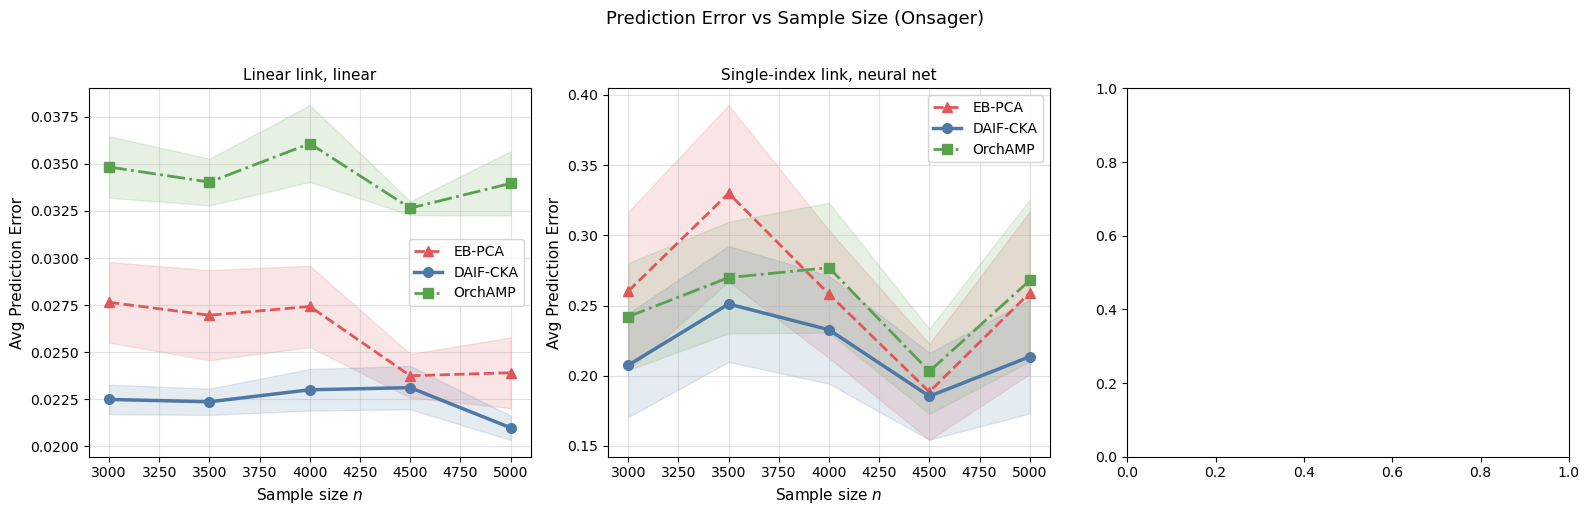

Saved ../Plots/pred_err_vs_n_onsager.png


In [9]:
# ---------------------------------------------------------------
# Line plots — mean pred error vs n, one panel per predictor setup
# ---------------------------------------------------------------
METHOD_STYLES = {
    "DAIF-CKA": {"marker": "o", "linestyle": "-",  "color": "#4E79A7", "lw": 2.5},
    "OrchAMP":  {"marker": "s", "linestyle": "-.", "color": "#59A14F", "lw": 2.0},
    "EB-PCA":   {"marker": "^", "linestyle": "--", "color": "#E15759", "lw": 2.0},
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (setup_label, _, _) in zip(axes, SETUPS):
    for strategy, label in STRATEGY_LABELS.items():
        means = np.array([summary[setup_label][strategy][n]['mean'] for n in N_VALUES])
        ses   = np.array([summary[setup_label][strategy][n]['se']   for n in N_VALUES])
        style = METHOD_STYLES[label]

        ax.plot(
            N_VALUES, means, label=label,
            marker=style['marker'], linestyle=style['linestyle'],
            color=style['color'], linewidth=style['lw'], markersize=7
        )
        ax.fill_between(
            N_VALUES, means - ses, means + ses,
            color=style['color'], alpha=0.15
        )

    ax.set_title(setup_label, fontsize=11)
    ax.set_xlabel('Sample size $n$', fontsize=11)
    ax.set_ylabel('Avg Prediction Error', fontsize=11)
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=10)

fig.suptitle('Prediction Error vs Sample Size (Onsager)', fontsize=13, y=1.02)
fig.tight_layout()

path = os.path.join(PLOTS_DIR, 'pred_err_vs_n_onsager.png')
fig.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {path}')